🚀 算力怪兽并发：重建域与锚定策略的物理博弈 (Models A, C, D) - Jupyter 完美线程版
[*] 正在 Jupyter 内启动 3 个独立运算线程，得益于 nogil=True，即将吃满 3 个 CPU 物理核...
[Model C: Forced Origin Scaling (k=8.07030550146298)] 完成! 耗时: 319.9s | a=322.694, b=0.000 | MSE=10.077
[Model D: Conjugate Full Spec Free Fit (k=8.782777700385054)] 完成! 耗时: 319.9s | a=308.199, b=0.000 | MSE=10.809
[Model A: Single-Point Anchoring (k=7.4294192030573)] 完成! 耗时: 321.9s | a=305.111, b=0.000 | MSE=20.224

[+] 物理原点博弈图已保存为 reconstruction_domain_analysis.png！


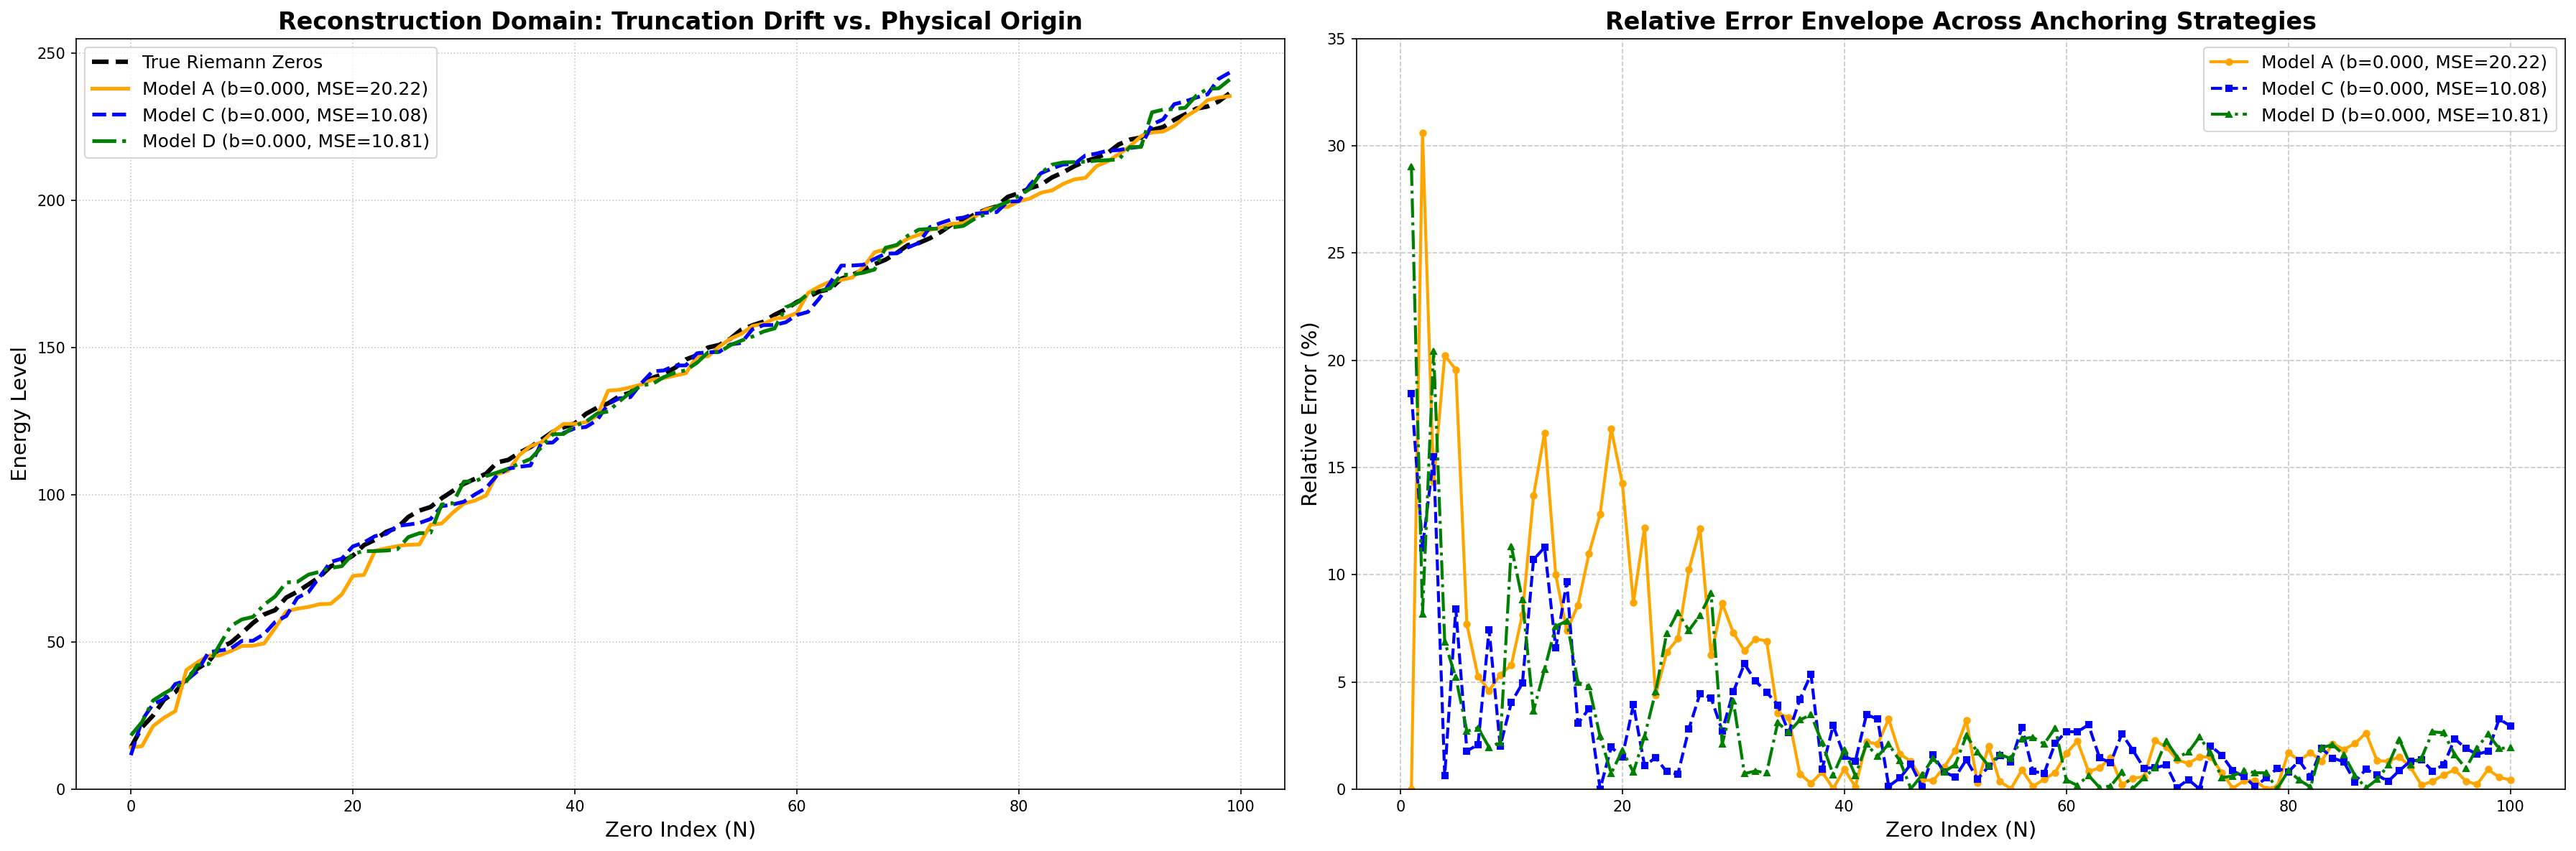

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath
from numba import njit
import time
import concurrent.futures

print("="*95)
print("🚀 算力怪兽并发：重建域与锚定策略的物理博弈 (Models A, C, D) - Jupyter 完美线程版")
print("="*95)

# ================= 1. 准备真实的黎曼零点 (100个) =================
N_compare = 100
mpmath.mp.dps = 15
true_zeros = np.array([float(mpmath.zetazero(i).imag) for i in range(1, N_compare + 1)])

# ================= 2. 绝对精度隔离的动力学内核 (释放 GIL！) =================
@njit(fastmath=True, nogil=True)
def dynamic_kernel(u_temp, k_opt, steps, n_bins, offset):
    x = 0.5
    counts = np.zeros((n_bins, n_bins), dtype=np.float64)
    last_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
    
    warmup_steps = 2000000 
    for i in range(warmup_steps):
        L_i = np.log(i + offset)
        u_dyn = u_temp + k_opt / (L_i**2)
        x = 1.0 - u_dyn * x**2
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
            
    for i in range(warmup_steps, steps + warmup_steps):
        L_i = np.log(i + offset)
        u_dyn = u_temp + k_opt / (L_i**2)
        x = 1.0 - u_dyn * x**2
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
        current_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
        if 0 <= current_bin < n_bins and 0 <= last_bin < n_bins: 
            counts[last_bin, current_bin] += 1
        last_bin = current_bin
    return counts

# ================= 3. 线程 Worker =================
def worker_task(task_info):
    name, k_val, model_type = task_info
    steps = 10_000_000_000  # 100 亿步
    offset = 100000.0
    n_bins = 2000
    u_c = 1.543689
    
    t0 = time.time()
    
    # 绝对环境隔离：计算高精度边界锚点
    t_end = 1.0 / (np.log(steps + offset)**2)
    u_temp = u_c - k_val * t_end
    
    counts = dynamic_kernel(u_temp, k_val, steps, n_bins, offset)
    
    row_sums = counts.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    P = counts / row_sums

    eigenvalues, _ = np.linalg.eig(P)
    valid_mask = (eigenvalues.imag > 1e-5) # 提取正能量态
    sim_pos = np.unwrap(np.sort(np.angle(eigenvalues[valid_mask])))
    
    N_actual = min(len(sim_pos), len(true_zeros))
    sim_pos = sim_pos[:N_actual]
    tz_pos = true_zeros[:N_actual]
    
    if model_type == 'A':
        # 单点绝对锚定，强行 b=0
        scale = tz_pos[0] / sim_pos[0]
        intercept = 0.0
        calib = scale * sim_pos
        
    elif model_type == 'C':
        # 全局比例缩放 (最小二乘法，强行 b=0)
        scale = np.dot(sim_pos, tz_pos) / np.dot(sim_pos, sim_pos)
        intercept = 0.0
        calib = scale * sim_pos
        
    elif model_type == 'D':
        # 全谱共轭自由拟合 (包含负能量态)
        sim_full = np.concatenate([-sim_pos[::-1], sim_pos])
        tz_full = np.concatenate([-tz_pos[::-1], tz_pos])
        
        # 自由释放 b 的束缚
        scale, intercept = np.polyfit(sim_full, tz_full, 1)
        # 取回正半轴用于绘图比对
        calib = scale * sim_pos + intercept
        
    rel_err = np.abs(calib - tz_pos) / tz_pos * 100
    mse = np.mean((calib - tz_pos)**2)
    
    print(f"[{name}] 完成! 耗时: {time.time()-t0:.1f}s | a={scale:.3f}, b={intercept:.3f} | MSE={mse:.3f}")
    
    pad_width = N_compare - N_actual
    full_calib = np.pad(calib, (0, pad_width), constant_values=np.nan)
    full_err = np.pad(rel_err, (0, pad_width), constant_values=np.nan)
    return name, full_calib, full_err, mse, intercept

# ================= 4. 主程序：一波流多线程并发 =================
if __name__ == "__main__":
    tasks = [
        ("Model A: Single-Point Anchoring (k=7.4294192030573)",  7.4294192030573, 'A'),
        ("Model C: Forced Origin Scaling (k=8.07030550146298)", 8.07030550146298, 'C'),
        ("Model D: Conjugate Full Spec Free Fit (k=8.782777700385054)", 8.782777700385054, 'D')
    ]
    
    print(f"[*] 正在 Jupyter 内启动 3 个独立运算线程，得益于 nogil=True，即将吃满 3 个 CPU 物理核...")
    
    # 使用 ThreadPoolExecutor 替换 ProcessPool，完美绕过 Jupyter 的 Pickle 问题！
    results = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=3) as executor:
        # map 保持返回顺序一致
        results = list(executor.map(worker_task, tasks))
        
    # ================= 5. 绘图对比 =================
    fig, axes = plt.subplots(1, 2, figsize=(24, 8), dpi=150)
    
    styles = [
        {'color': 'orange', 'linestyle': '-', 'marker': 'o'},     # A
        {'color': 'blue', 'linestyle': '--', 'marker': 's'},      # C
        {'color': 'green', 'linestyle': '-.', 'marker': '^'}      # D
    ]

    axes[0].plot(true_zeros, 'k--', linewidth=3, label='True Riemann Zeros')
    
    for i, res in enumerate(results):
        name, calib, err, mse, intercept = res
        style = styles[i]
        label_str = f"{name.split(':')[0]} (b={intercept:.3f}, MSE={mse:.2f})"
        
        # 图 1：能级预测
        axes[0].plot(calib, color=style['color'], linestyle=style['linestyle'], linewidth=2.5, label=label_str)
        # 图 2：相对误差
        axes[1].plot(np.arange(1, N_compare + 1), err, color=style['color'], linestyle=style['linestyle'], 
                     marker=style['marker'], markersize=4, linewidth=2, label=label_str)

    axes[0].set_title("Reconstruction Domain: Truncation Drift vs. Physical Origin", fontsize=16, fontweight='bold')
    axes[0].set_xlabel("Zero Index (N)", fontsize=14)
    axes[0].set_ylabel("Energy Level", fontsize=14)
    axes[0].legend(loc='upper left', fontsize=12)
    axes[0].grid(True, linestyle=':', alpha=0.7)

    axes[1].set_title("Relative Error Envelope Across Anchoring Strategies", fontsize=16, fontweight='bold')
    axes[1].set_xlabel("Zero Index (N)", fontsize=14)
    axes[1].set_ylabel("Relative Error (%)", fontsize=14)
    axes[1].legend(loc='upper right', fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.7)
    axes[1].set_ylim(0, 35) 

    plt.tight_layout()
    plt.savefig("reconstruction_domain_analysis.png")
    print("\n[+] 物理原点博弈图已保存为 reconstruction_domain_analysis.png！")
    plt.show()